/tmp/ipykernel_2423/3813825049.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training RNN

Training LSTM

Training GRU


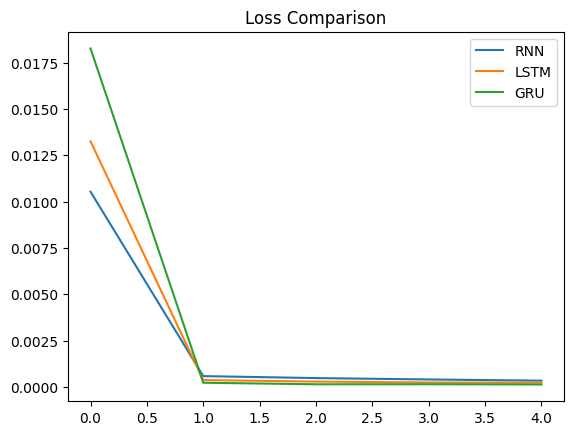

RNN: Time=3.50s, Loss=0.00630
LSTM: Time=3.21s, Loss=0.00108
GRU: Time=3.32s, Loss=0.00068


In [ ]:
# ==============================
# LAB 4: REAL STOCK DATA
# ==============================

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

# Load stock data
data = yf.download("AAPL", start="2015-01-01", end="2023-01-01")

prices = data['Close'].values.reshape(-1,1)

# Normalize
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)

# Create sequences
def create_dataset(data, timesteps=10):
    X, y = [], []
    for i in range(len(data)-timesteps):
        X.append(data[i:i+timesteps])
        y.append(data[i+timesteps])
    return np.array(X), np.array(y)

X, y = create_dataset(prices)

# Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Model builder
def build_model(model_type):
    model = Sequential()
    if model_type == "RNN":
        model.add(SimpleRNN(32, input_shape=(10,1)))
    elif model_type == "LSTM":
        model.add(LSTM(32, input_shape=(10,1)))
    elif model_type == "GRU":
        model.add(GRU(32, input_shape=(10,1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

models = ["RNN", "LSTM", "GRU"]
results = {}

for m in models:
    print(f"\nTraining {m}")
    model = build_model(m)

    start = time.time()
    history = model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    end = time.time()

    loss = model.evaluate(X_test, y_test, verbose=0)
    results[m] = (history.history['loss'], end-start, loss)

# Plot
for m in models:
    plt.plot(results[m][0], label=m)

plt.legend()
plt.title("Loss Comparison")
plt.show()

# Results
for m in models:
    print(f"{m}: Time={results[m][1]:.2f}s, Loss={results[m][2]:.5f}")